In [1]:
###Select folder and protein to analyze
path = 'E:/Augusto/Images/SoRa/23042024-SoRa' #avoid writing a dash / at the end
protein = 'EGFP'

#path = 'D:/Augusto/Images/SoRa/23042024-SoRa' #avoid writing a dash / at the end
#protein = 'EGFP'

#Define square size
square_size = 1000

#Define which channel corresponds to fluorescent protein and which one corresponds to nucleus marker ('fp' or 'nucleus')
ch1 = 'protein'
ch2 = 'beads'


In [2]:
###Iterate and save the names of the imaging files (from the same protein) to analyze

def list_protein_folders(path, protein):
    # Initialize an empty list to store file names
    protein_folders = []

    # Iterate over all relevant folders in the date folder
    for foldername in os.listdir(path):
        # Check if the file ends with the specified suffix
        if foldername.startswith(protein):
            # Add the file to the list
            protein_folders.append(os.path.join(path, foldername))

    return protein_folders

# # Example usage:
# protein_folders = list_protein_folders(path, protein)
# print("Folders with prefix '{}':".format(protein))
# for protein_folder in protein_folders:
#     print(protein_folder)

In [3]:
#This function reads ome tif files generated by micro manager.
#It takes the path to your files, the genotype (as my data is organized in folders named after the genotype of the imaged cells)
#and dataset number to select one of the datasets in the genotype folder
def readDataset(protein_folder):
        
    os.chdir(protein_folder)
    print(os.getcwd())
    
    DatasetsinFolder = os.listdir()
    print(DatasetsinFolder)
    
    for element in DatasetsinFolder:
        if ".ome.tif" in element: #".ome.tif"
            Dataset = element
            print("input file:", Dataset)
            break
    
    image_stack = io.imread(Dataset, plugin='pil') #We need to read the .ome files with 'pil' plugin due to bugs recognizing the shape of the files in other formats
    #print(image_stack.shape) #the shape of these ome.tif files should be 2 channels, 54 stacks, and 2048 times 2048 images

    return image_stack


In [4]:
def setDatasetChannels(image_stack, ch1, ch2):

    image_shape = np.shape(image_stack) 
    
    #The resulting shape of the dataset has the two channels stacked on each other. 
    no_of_channels = len(image_shape) - 1 #Retrieving the number of channels in our dataset.

    #Thus, the stack is divided by the number of channels, and each slice assigned to a channel.
    stacks_perChannel = int(np.shape(image_stack)[0] / no_of_channels)

    print("stacks per channel: ", stacks_perChannel)
    print("shape of dataset: ", (np.shape(image_stack))) #shape of the read dataset using pil (stacks X channels, y pixels, x pixels)

    #Setting the last slices for each channel (due to python 0-indexing)
    last_image_ch1_slice = stacks_perChannel
    last_image_ch2_slice = stacks_perChannel * 2

    # print("last_image_fp_slice", last_image_fp_slice)
    # print("last_image_spy650_slice", last_image_spy650_slice)

    image_ch1 = image_stack[0:last_image_ch1_slice, :, :] 
    image_ch2 = image_stack[stacks_perChannel:last_image_ch2_slice, :, :]
    #plt.imshow(image_stack[0, :, :])

    #Assign proper channels to corresponding variables for further analysis
    if ch1 == 'protein':
        image_chProtein = image_ch1
    elif ch1 == 'beads':
        image_chBeads = image_ch1
    else:
        raise ValueError("ch1 must be either 'protein' or 'beads'")

    if ch2 == 'beads':
        image_chBeads = image_ch2
    elif ch2 == 'protein':
        image_chProtein = image_ch2
    else:
        raise ValueError("ch2 must be either 'protein' or 'beads'")
        
    return(image_chProtein, image_chBeads)
        
        

In [5]:
#Function to select a square in the center of image
import matplotlib.patches as patches

# image_selected = image_stack[15].copy()
# square_size = 1000

def center_square(image_selected, square_size):
    
    # Obtain hight and with of original image
    image_hight = np.shape(image_protein_stack)[1]
    image_width = np.shape(image_protein_stack)[2]
    
    top_square = int((image_hight - square_size) / 2)
    left_square = int((image_width - square_size) / 2)
    bottom_square = int(top_square + square_size)
    right_square = int(left_square + square_size)

#     print('top_square', top_square)
#     print('left_square', left_square)
#     print('bottom_square', bottom_square)
#     print('right_square', right_square)

    mean_image_selected = np.mean(image_selected[top_square:bottom_square, left_square:right_square])

    ###plot images (keep as comment)
    #Display images
    # Create figure and axes
#     fig, ax = plt.subplots()

#     # Display the image
#     ax.imshow(image_selected)
    
#     #Create and add a rectangle patch
#     rect = patches.Rectangle((left_square, top_square), square_size, square_size, linewidth=3, edgecolor='w', facecolor='none')
#     ax.add_patch(rect)
    
#     plt.show()
#     image_selected[top_square:bottom_square, left_square:right_square] = 0
#     plt.imshow(image_selected)    
    ###
    
    return(mean_image_selected)

# mean_image_selected = center_square(image_selected, square_size)
                                                 
# print('mean_image_selected', mean_image_selected)

In [6]:
#####Select folder, dataset, and channels
#######
#######
#This code implements functions for reading tif.ome files

import os
import re
import skimage 
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import tifffile as tf
import pandas as pd
import re

#print(skimage.__version__)
#skimage reference
#Stéfan van der Walt, Johannes L. Schönberger, Juan Nunez-Iglesias, François Boulogne, Joshua D. Warner, Neil Yager, Emmanuelle Gouillart, Tony Yu and the scikit-image contributors. scikit-image: Image processing in Python. PeerJ 2:e453 (2014) https://doi.org/10.7717/peerj.453
#https://biomedicalhub.github.io/python-data/skimage.html - Read about image processing skimage

# Create an empty DataFrame with columns
date_dfe = []
protein_dfe = []
concentration_dfe = []
dataset_dfe = []
slice_dfe = []
mean_dfe = []
square_dfe = []

# Information to plot
#Vector with mean values per slice
#Name of each concentration dataset for colors

protein_folders = list_protein_folders(path, protein)
print("Folders with prefix '{}':".format(protein))
for protein_folder in protein_folders:
    print(protein_folder)
    
    #Read dataset and select channel to analyze
    image_stack = readDataset(protein_folder)
    image_protein_stack, image_beads_stack = setDatasetChannels(image_stack, ch1, ch2)
    
    #image_protein_shape = np.shape(image_protein_stack) 
    #print(image_protein_shape)

    for index, Zslice in enumerate(image_protein_stack):
        
        image_selected = image_protein_stack[index].copy()
        mean_image_selected = center_square(image_selected, square_size)
        #print('mean slice',  index, ':', mean_image_selected)
        
        date_e = path.split('/')[-1]
        print("date_e", date_e)
        protein_e = protein
        print("protein_e", protein_e)
        concentration_e = re.findall(r'-(\d+)nM', protein_folder)[0]
        print("concentration_e", concentration_e)
        dataset_e = re.findall(r'_(\d+)', protein_folder)[0]
        print("dataset_e", dataset_e)
        slice_e = index
        print("slice_e", slice_e)
        mean_e = mean_image_selected
        print("mean_e", mean_e)
        square_e = square_size
        print("square_e", square_e)
        
        date_dfe.append(date_e)
        protein_dfe.append(protein_e)
        concentration_dfe.append(concentration_e)
        dataset_dfe.append(dataset_e)
        slice_dfe.append(slice_e)
        mean_dfe.append(mean_e)
        square_dfe.append(square_e)
        #save in dataframe
        #date #protein #dataset #slice #mean 
    
# Create an empty DataFrame with columns
df_protein = pd.DataFrame({"date": date_dfe, "protein": protein_dfe, "concentration": concentration_dfe, "dataset": dataset_dfe, "slice": slice_dfe, "mean": mean_dfe, "square": square_dfe})   


Folders with prefix 'EGFP':
E:/Augusto/Images/SoRa/23042024-SoRa\EGFP-0nM_1
E:\Augusto\Images\SoRa\23042024-SoRa\EGFP-0nM_1
['comments.txt', 'DisplaySettings.json', 'EGFP-0nM_1_MMStack_Pos0.ome.tif']
input file: EGFP-0nM_1_MMStack_Pos0.ome.tif
stacks per channel:  41
shape of dataset:  (82, 2100, 2300)
date_e 23042024-SoRa
protein_e EGFP
concentration_e 0
dataset_e 1
slice_e 0
mean_e 102.400523
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 0
dataset_e 1
slice_e 1
mean_e 102.823454
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 0
dataset_e 1
slice_e 2
mean_e 102.58822
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 0
dataset_e 1
slice_e 3
mean_e 102.658711
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 0
dataset_e 1
slice_e 4
mean_e 102.765003
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 0
dataset_e 1
slice_e 5
mean_e 102.595971
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration

stacks per channel:  41
shape of dataset:  (82, 2100, 2300)
date_e 23042024-SoRa
protein_e EGFP
concentration_e 0
dataset_e 3
slice_e 0
mean_e 102.459584
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 0
dataset_e 3
slice_e 1
mean_e 102.498548
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 0
dataset_e 3
slice_e 2
mean_e 102.543171
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 0
dataset_e 3
slice_e 3
mean_e 102.731335
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 0
dataset_e 3
slice_e 4
mean_e 102.545624
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 0
dataset_e 3
slice_e 5
mean_e 102.62371
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 0
dataset_e 3
slice_e 6
mean_e 102.524051
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 0
dataset_e 3
slice_e 7
mean_e 102.598087
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 0
dataset_e 3
slice_e 8
m

stacks per channel:  41
shape of dataset:  (82, 2100, 2300)
date_e 23042024-SoRa
protein_e EGFP
concentration_e 100
dataset_e 1
slice_e 0
mean_e 110.451039
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 100
dataset_e 1
slice_e 1
mean_e 110.654133
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 100
dataset_e 1
slice_e 2
mean_e 110.628628
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 100
dataset_e 1
slice_e 3
mean_e 110.853684
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 100
dataset_e 1
slice_e 4
mean_e 110.775794
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 100
dataset_e 1
slice_e 5
mean_e 110.919439
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 100
dataset_e 1
slice_e 6
mean_e 110.999503
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 100
dataset_e 1
slice_e 7
mean_e 111.207672
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 100
data

stacks per channel:  41
shape of dataset:  (82, 2100, 2300)
date_e 23042024-SoRa
protein_e EGFP
concentration_e 100
dataset_e 3
slice_e 0
mean_e 110.508159
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 100
dataset_e 3
slice_e 1
mean_e 110.791582
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 100
dataset_e 3
slice_e 2
mean_e 110.745267
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 100
dataset_e 3
slice_e 3
mean_e 110.695115
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 100
dataset_e 3
slice_e 4
mean_e 110.73099
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 100
dataset_e 3
slice_e 5
mean_e 110.813701
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 100
dataset_e 3
slice_e 6
mean_e 110.766425
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 100
dataset_e 3
slice_e 7
mean_e 110.796207
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 100
datas

stacks per channel:  41
shape of dataset:  (82, 2100, 2300)
date_e 23042024-SoRa
protein_e EGFP
concentration_e 200
dataset_e 1
slice_e 0
mean_e 120.402209
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 200
dataset_e 1
slice_e 1
mean_e 120.609965
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 200
dataset_e 1
slice_e 2
mean_e 120.88096
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 200
dataset_e 1
slice_e 3
mean_e 120.824333
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 200
dataset_e 1
slice_e 4
mean_e 120.854039
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 200
dataset_e 1
slice_e 5
mean_e 121.088657
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 200
dataset_e 1
slice_e 6
mean_e 121.150035
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 200
dataset_e 1
slice_e 7
mean_e 121.375121
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 200
datas

...

stacks per channel:  41
shape of dataset:  (82, 2100, 2300)
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 1
slice_e 0
mean_e 164.685643
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 1
slice_e 1
mean_e 164.739964
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 1
slice_e 2
mean_e 164.928582
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 1
slice_e 3
mean_e 165.745544
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 1
slice_e 4
mean_e 166.370287
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 1
slice_e 5
mean_e 166.607593
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 1
slice_e 6
mean_e 167.237438
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 1
slice_e 7
mean_e 167.887962
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
data

date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 2
slice_e 31
mean_e 185.662266
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 2
slice_e 32
mean_e 186.608897
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 2
slice_e 33
mean_e 186.662391
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 2
slice_e 34
mean_e 187.878975
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 2
slice_e 35
mean_e 187.905194
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 2
slice_e 36
mean_e 188.736456
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 2
slice_e 37
mean_e 189.460992
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 2
slice_e 38
mean_e 189.751537
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 2
slice_e 39
mean_e 190.397249
square_e 1000
d

date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 4
slice_e 26
mean_e 179.085746
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 4
slice_e 27
mean_e 179.46583
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 4
slice_e 28
mean_e 179.752764
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 4
slice_e 29
mean_e 180.141545
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 4
slice_e 30
mean_e 180.475534
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 4
slice_e 31
mean_e 180.690206
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 4
slice_e 32
mean_e 181.285812
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 4
slice_e 33
mean_e 181.390283
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 500
dataset_e 4
slice_e 34
mean_e 181.654714
square_e 1000
da

date_e 23042024-SoRa
protein_e EGFP
concentration_e 50
dataset_e 2
slice_e 26
mean_e 107.105002
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 50
dataset_e 2
slice_e 27
mean_e 107.000638
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 50
dataset_e 2
slice_e 28
mean_e 107.066238
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 50
dataset_e 2
slice_e 29
mean_e 107.179237
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 50
dataset_e 2
slice_e 30
mean_e 107.056972
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 50
dataset_e 2
slice_e 31
mean_e 107.073543
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 50
dataset_e 2
slice_e 32
mean_e 107.256846
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 50
dataset_e 2
slice_e 33
mean_e 107.044695
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 50
dataset_e 2
slice_e 34
mean_e 107.083037
square_e 1000
date_e 230

date_e 23042024-SoRa
protein_e EGFP
concentration_e 50
dataset_e 4
slice_e 28
mean_e 107.280442
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 50
dataset_e 4
slice_e 29
mean_e 107.33509
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 50
dataset_e 4
slice_e 30
mean_e 107.313408
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 50
dataset_e 4
slice_e 31
mean_e 107.317225
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 50
dataset_e 4
slice_e 32
mean_e 107.357703
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 50
dataset_e 4
slice_e 33
mean_e 107.399205
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 50
dataset_e 4
slice_e 34
mean_e 107.243258
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 50
dataset_e 4
slice_e 35
mean_e 107.360637
square_e 1000
date_e 23042024-SoRa
protein_e EGFP
concentration_e 50
dataset_e 4
slice_e 36
mean_e 107.322694
square_e 1000
date_e 2304

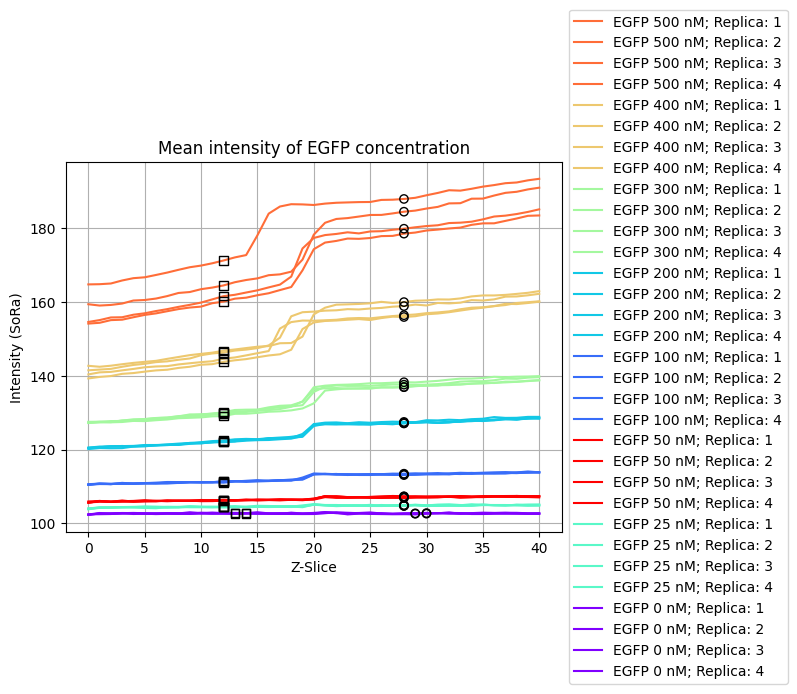

In [10]:
import itertools
import matplotlib.pyplot as plt

###Draw plots and extract other meaningful information
# Create a plot
plt.figure()
# Create an empty list to store legend labels
legend_labels = []

#Create empty output lists
date_output = []
protein_output = []
dataset_output = []
concentration_nM_output = []
in_4um_slices_output = []
in_4um_means_output = []
out_4um_slices_output = []
out_4um_means_output = []
concentration_nM_output = []

# Select all unique values in the 'protein', 'concentration', and 'dataset' column
unique_proteins = df_protein['protein'].unique()
#print("unique_proteins:", unique_proteins)

unique_concentrations = df_protein['concentration'].unique()
#print("unique_concentrations:", unique_concentrations)

####set colors for each concentration
####
# Map unique concentrations to numerical values
unique_concentrations_numeric = unique_concentrations.astype(int)
sorted_concentrations_numeric = np.sort(unique_concentrations_numeric)
unique_concentrations_sorted = sorted_concentrations_numeric.astype(str)

concentration_mapping = {concentration: i for i, concentration in enumerate(unique_concentrations_sorted)}
# Define colors based on the number of unique concentrations
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_concentrations_sorted)))
#print(colors)
####
####

unique_datasets = df_protein['dataset'].unique()
#print("unique_datasets:", unique_datasets)

# Get all unique combinations of protein, concentration, and dataset. Columns that share all three values correspond to slices from the same dataset 
unique_proteins_concentrations_datasets = list(itertools.product(unique_proteins, unique_concentrations, unique_datasets))
# Sort the list by the integer values of unique_concentrations
unique_proteins_concentrations_datasets = sorted(unique_proteins_concentrations_datasets, key=lambda x: int(x[1]), reverse=True)
#print(unique_proteins_concentrations_datasets)

# Iterate through all indexes (rows) in the DataFrame
for shared_values in unique_proteins_concentrations_datasets:
        
    shared_values_protein, shared_values_concentration, shared_values_dataset = shared_values
    #print(shared_values_protein, shared_values_concentration, shared_values_dataset)
    
    # Boolean indexing to select rows that share all three values
    selected_df_protein_rows = df_protein[
         (df_protein['protein'] == shared_values_protein) &
         (df_protein['concentration'] == shared_values_concentration) &
         (df_protein['dataset'] == shared_values_dataset)]
    
    # Print selected rows
    #print(selected_df_protein_rows, "\n")
     
    #Do whatever is needed with the selected rows
    # Plot each set of shared values and store the label
    max_mean_index = selected_df_protein_rows['mean'].idxmax()
    max_mean_slice = selected_df_protein_rows.loc[max_mean_index, 'slice']
    #print(max_mean_index)
    
    if max_mean_slice < 15 or max_mean_slice > 25:
        midindex = len(selected_df_protein_rows['mean']) // 2
        max_mean_index = selected_df_protein_rows['mean'].index[midindex]
        
    in_4um_index = max_mean_index + 8 #8 slices are equivalent to 4um
    out_4um_index = max_mean_index - 8 #8 slices are equivalent to 4um

    date_o = selected_df_protein_rows.loc[in_4um_index, 'date']
    protein_o = selected_df_protein_rows.loc[in_4um_index, 'protein']
    concentration_nM_o = selected_df_protein_rows.loc[in_4um_index, 'concentration']
    dataset_o = selected_df_protein_rows.loc[in_4um_index, 'dataset']
    in_4um_slices_o = selected_df_protein_rows.loc[in_4um_index, 'slice']
    in_4um_means_o = selected_df_protein_rows.loc[in_4um_index, 'mean']
    
    out_4um_slices_o = selected_df_protein_rows.loc[out_4um_index, 'slice']
    out_4um_means_o = selected_df_protein_rows.loc[out_4um_index, 'mean']

    
    date_output.append(date_o)
    protein_output.append(protein_o)
    concentration_nM_output.append(concentration_nM_o)
    dataset_output.append(dataset_o)
    in_4um_slices_output.append(in_4um_slices_o)
    in_4um_means_output.append(in_4um_means_o)
    out_4um_slices_output.append(out_4um_slices_o)
    out_4um_means_output.append(out_4um_means_o)
    
    # Find the index of the given string in the NumPy array
    index_concentration = np.where(unique_concentrations == shared_values_concentration)[0]
    #print(index_concentration)
    
    plt.plot(selected_df_protein_rows['slice'], selected_df_protein_rows['mean'], color = colors[index_concentration])
    legend_labels.append(f"{shared_values_protein} {shared_values_concentration} nM; Replica: {shared_values_dataset}")
    
# Add labels, title, legend, and grid
plt.xlabel('Z-Slice')
plt.ylabel('Intensity (SoRa)')
plt.title(f'Mean intensity of {protein} concentration')

#plt.xlim([10,40])
#plt.ylim([100,130]) #values for mCherry-SPARKOFF
#plt.ylim([100,200]) #values for mCherry-SPARKOFF


plt.grid(True)

plt.scatter(in_4um_slices_output, in_4um_means_output, marker='o', facecolors='none', edgecolors='black', zorder=10)
plt.scatter(out_4um_slices_output, out_4um_means_output, marker='s', facecolors='none', edgecolors='black', zorder=10)

# Create a legend outside the plot area
plt.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5))

# Show the plot with all overlapped plots
plt.show()

df_output = pd.DataFrame({"date": date_output, "protein": protein_output, "concentration": concentration_nM_output, "dataset": dataset_output, "slicein": in_4um_slices_output, "meanin": in_4um_means_output, "sliceout": out_4um_slices_output, "meanout": out_4um_means_output})   


In [8]:
print(df_output)

# Specify the file path where you want to save the text file
file_path = path + '/' + path.split('/')[-1] + '-' + protein + '_calibration_output.txt'
print(file_path)
# Print the DataFrame to the text file
#df_output.to_csv(file_path, index=False, sep='\t')  # Use '\t' as the separator for tab-separated values

print("DataFrame has been printed to", file_path)

             date protein concentration dataset  slicein      meanin  \
0   23042024-SoRa    EGFP           500       1       28  187.810794   
1   23042024-SoRa    EGFP           500       2       28  184.359705   
2   23042024-SoRa    EGFP           500       3       28  178.421460   
3   23042024-SoRa    EGFP           500       4       28  179.752764   
4   23042024-SoRa    EGFP           400       1       28  159.895388   
5   23042024-SoRa    EGFP           400       2       28  155.856755   
6   23042024-SoRa    EGFP           400       3       28  158.812439   
7   23042024-SoRa    EGFP           400       4       28  156.342875   
8   23042024-SoRa    EGFP           300       1       28  138.208262   
9   23042024-SoRa    EGFP           300       2       28  137.549785   
10  23042024-SoRa    EGFP           300       3       28  136.926372   
11  23042024-SoRa    EGFP           300       4       28  136.870299   
12  23042024-SoRa    EGFP           200       1       28  127.46